## Mode Imputatuon (for categorical data)
##using pandas

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df= pd.read_csv("/content/train (1).csv" ,usecols=['GarageQual','FireplaceQu','SalePrice'])

In [12]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [16]:
df.isnull().mean() *100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


## FirePlaceQu-> has around 47% missing values
and `garageQual` has around 5% so we can apply most frequent value Imputation


Text(0.5, 1.0, 'GarageQual Count')

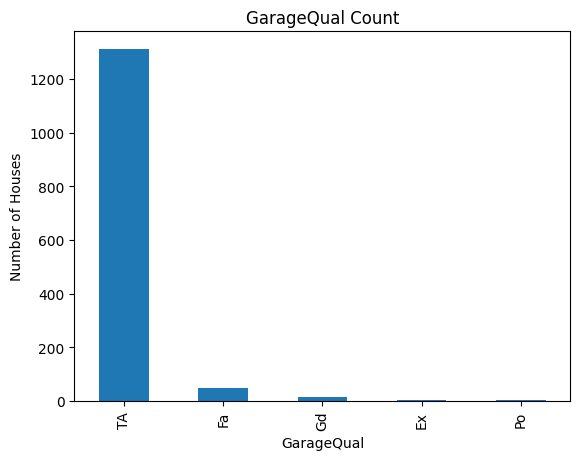

In [18]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')
plt.title("GarageQual Count")

In [19]:
df['GarageQual'].mode()

,GarageQual
0,TA


## Without applying any Imputation: to `GarageQual` columm


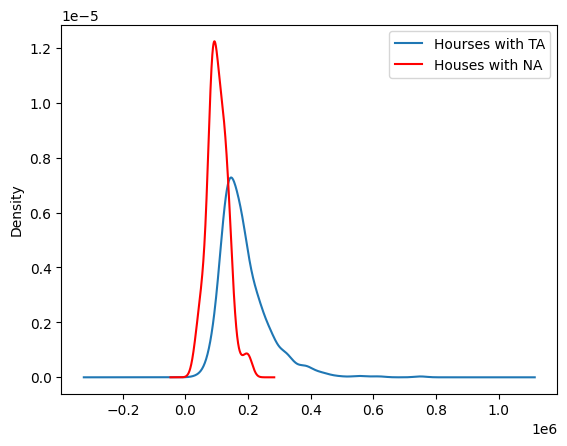

In [22]:
fig =plt.figure()
ax= fig.add_subplot(111)
df[df['GarageQual']=="TA"]['SalePrice'].plot(kind="kde",ax= ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()

labels=['Hourses with TA','Houses with NA']
ax.legend(lines,labels,loc='best')

In [23]:
temp = df[df['GarageQual']=="TA"]['SalePrice']


In [24]:
df['GarageQual'].fillna("TA",inplace =True)

/tmp/ipykernel_832/3411965277.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna("TA",inplace =True)


## this will impute missing values with TA as well that's why the height of bar('TA') increases.

<Axes: xlabel='GarageQual'>

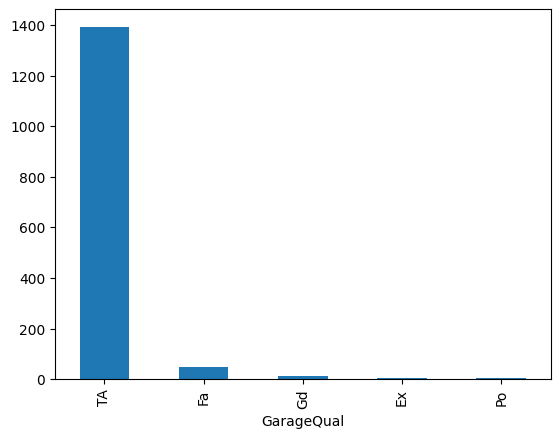

In [25]:
df['GarageQual'].value_counts().plot(kind='bar')

## Comparison after imputing missing values with Mode-most frequqntly used variables

Text(0.5, 1.0, 'GarageQual')

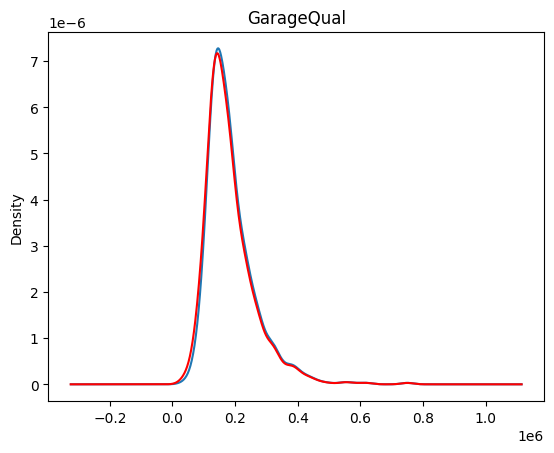

In [28]:
fig =plt.figure()
ax= fig.add_subplot(111)

temp.plot(kind="kde",ax= ax)

#after imputation
df[df['GarageQual']=="TA"]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()

labels=['OG variables','Imputed variables']

plt.title("GarageQual")


## since the missing values were almost 5% that's why the distribution remains same before and after imputation.

## Appling same technique on `FireplaceQUal`

<Axes: xlabel='FireplaceQu'>

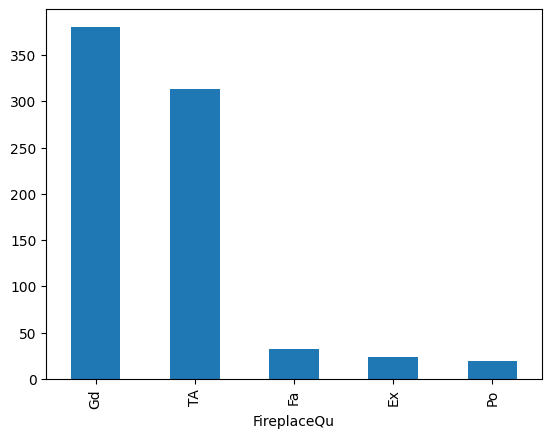

In [30]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()


# to apply mode imputation, only one category should dominate but here two of them are dominating.

In [31]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

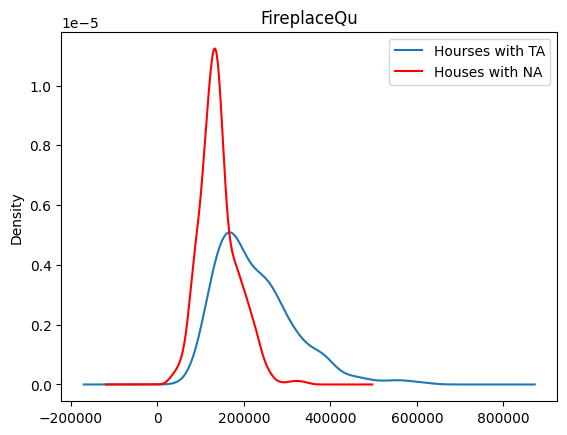

In [33]:
fig =plt.figure()
ax= fig.add_subplot(111)
df[df['FireplaceQu']=="Gd"]['SalePrice'].plot(kind="kde",ax= ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines, labels = ax.get_legend_handles_labels()

labels=['Hourses with TA','Houses with NA']
ax.legend(lines,labels,loc='best')
plt.title("FireplaceQu")

In [34]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [35]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_832/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

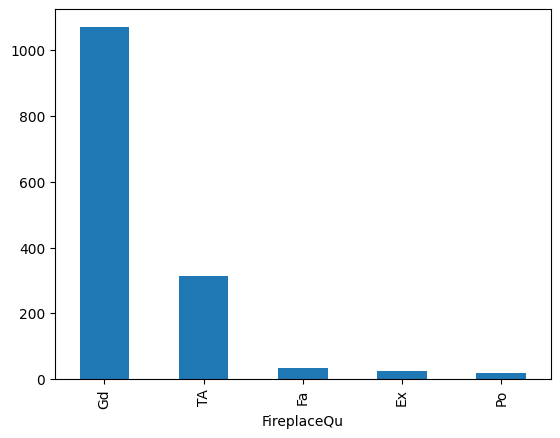

In [36]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

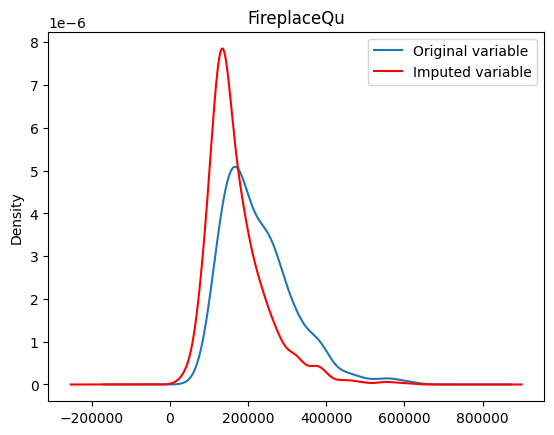

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

## Mode value Imputation using Sklearn

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [39]:
from sklearn.impute import SimpleImputer
imputer =SimpleImputer(strategy="most_frequent")

In [40]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [41]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)